In [28]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt
import io

In [51]:
# movie_data = reader.read(fpath="./data/indexed_movies.csv", sep=",", fmt="UIRT")
# movie_data
movies = pd.read_csv("./cornac/data_c/indexed_movies.csv")

movies = movies.drop(columns=movies.columns[0])
movies[:4]

# unique_genres = set("|".join(movies["genres"]).split("|"))
# unique_genres = list(unique_genres)
unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
for genre in unique_genres:
    movies[genre] = 0
for index, row in movies.iterrows():
    genres = row["genres"].split("|")
    for genre in genres:
        movies.at[index, genre] = 1

# item_categories = movies[unique_genres]
# unique_iids = rating_data_pd['itemID'].unique()
# movies = movies[movies['itemID'].isin(unique_iids)]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()
# print(item_features_numpy.shape)

# item_categories = item_categor
item_features = {
    str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
ids = list(range(0, 3416))
# item_feature_modality = FeatureModality(
#     features=item_features_numpy, ids=ids, normalized=True
# )


users = pd.read_csv("./cornac/data_c/u_id_mapping.csv", sep="\t")
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
# unique_uids = rating_data_pd['userID'].unique()

# users = users[users["userID"].isin(unique_uids)]
user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
print(item_features_numpy.shape)
# user_feature_modality = FeatureModality(
#     features=user_features_numpy, name="user", normalized=True, ids=list(range(0, 6040))
# )

# print("Example Item Features:")
# for item_id, features in list(item_features.items())[:5]:
#     print(f"Item ID: {item_id}, Features: {features}")

(6040, 2)
(3416, 18)


In [2]:
reco_matrix=np.load("reco_matrix.npy")
reco_matrix_mapped_items=np.load("reco_matrix_mapped_items.npy")
reco_matrix_mapped_scores= np.load("reco_matrix_mapped_scores.npy")
reco_matrix_all= np.load("reco_matrix_all.npy")
# np.load("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [38]:
reco_matrix[1][1]

array([ 167,   45,  764,  113,  142,  190,  164,   60,  322,   48,  398,
       1333, 2697,   85,  505,   38,  207,  273, 1313, 2516])

In [36]:
with open('reranked_recommendations.csv', 'r') as file:
    csv_content = file.read()
csv_content = csv_content.replace('"', '')
csv_io = io.StringIO(csv_content)
reranked_list = pd.read_csv(csv_io,delimiter=",", header=None, quotechar='"', index_col=0)
reranked_list.columns = [f"top_{i+1}" for i in range(reranked_list.shape[1])]
reranked_list.index.name = 'UserID'

In [37]:
reranked_list

,top_1,top_2,top_3,top_4,top_5,top_6,top_7,top_8,top_9,top_10,top_11,top_12,top_13,top_14,top_15,top_16,top_17,top_18,top_19,top_20
UserID,,,,,,,,,,,,,,,,,,,,
0,1767,25,1562,611,2316,681,696,3244,2102,162,408,298,101,1884,906,1322,1860,1033,2091,2278
1,91,189,2042,2210,156,1663,2146,1918,437,1141,2424,2404,489,915,319,311,538,1950,665,2715
2,189,623,1797,1341,2952,1317,1708,3160,193,2676,2907,2790,1866,2757,2215,197,1617,2791,1890,2260
3,124,1003,213,720,2311,57,372,949,2287,2807,455,2637,1711,959,6,1661,969,957,156,1556
4,590,229,740,104,1583,798,92,2711,1384,516,787,1231,371,3036,1929,1442,181,1844,132,402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,911,988,559,438,1139,747,897,1832,1919,3079,1558,2413,2348,2469,1725,2066,2974,3046,183,325
2696,1058,5,893,236,662,209,1925,486,196,3231,217,550,3098,2884,87,2405,211,685,1988,3164
2697,1920,1053,3088,1824,76,995,3251,2663,552,3410,3238,3235,1437,47,1635,582,22,1529,1751,505


In [47]:
reco_matrix_normal = reco_matrix[1][0:2700]

In [46]:
reo_matrix_reranked = reranked_list.values
reo_matrix_reranked[2699]

array([ 347, 1612,  623, 1728, 1873,  565, 1240,  182,  172, 1638,  950,
         40,  301, 1371,   81,  259, 1822, 1328,  794, 3317])

In [49]:
reco_matrix_normal.shape

(2700, 20)

In [50]:
reo_matrix_reranked.shape

(2700, 20)

In [59]:
reco_matrix=[]
reco_matrix.append(reco_matrix_normal)
reco_matrix.append(reo_matrix_reranked)
reco_matrix[0].shape

(2700, 20)

In [60]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

top_k = 20
###intialize them
gp = GenrePrecision(users, unique_genres, top_k)
gr = GenreRecall(users, unique_genres, top_k)
gm = GenreMap(users, unique_genres, top_k)
gndcg = GenreNDCG(users, unique_genres, top_k)
gmrr = GenreMRR(users, unique_genres, top_k)

user_ids = users.to_numpy()[:, 1]
item_ids = movies.to_numpy()[:, 2]
user_ids.__len__()

6040

In [61]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((1, len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(1):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[1][u][:new_top_k]


grp = GenreRPrecision(users, unique_genres, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [62]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(reco_matrix)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], movies))
    ####Recall####
    model_grs.append(gr.compute(reco_matrix[i], movies))
    ####MAP Mean Average Precision####
    model_gms.append(gm.compute(reco_matrix[i], movies))
    ####DCG####
    model_gdcgs.append(gndcg.compute(reco_matrix[i], movies))
    ####MRR####
    model_gmrrs.append(gmrr.compute(reco_matrix[i], movies))
    
    
# model_gp = gp.compute(reco_matrix[0], movies)
# model_gp_2 = gp.compute(reco_matrix[1], movies)
# model_gp_3 = gp.compute(reco_matrix[2], movies)
# model_gp_4 = gp.compute(reco_matrix[3], movies)
# model_gp_5 = gp.compute(reco_matrix[4], movies)


####IR Metrics####
# model_gr = gr.compute(reco_matrix[0], movies)
# model_gr_2 = gr.compute(reco_matrix[1], movies)
# model_gr_3 = gr.compute(reco_matrix[2], movies)
# model_gr_4 = gr.compute(reco_matrix[3], movies)
# model_gr_5 = gr.compute(reco_matrix[4], movies)
####IR Metrics####
####MAP Mean Average Precision####
# model_gm = gm.compute(reco_matrix[0], movies)
# model_gm_2 = gm.compute(reco_matrix[1], movies)
# model_gm_3 = gm.compute(reco_matrix[2], movies)
# model_gm_4 = gm.compute(reco_matrix[3], movies)
# model_gm_5 = gm.compute(reco_matrix[4], movies)
####IR Metrics####
####DCG####
# model_gdcg = gndcg.compute(reco_matrix[0], movies)
# model_gdcg_2 = gndcg.compute(reco_matrix[1], movies)
# model_gdcg_3 = gndcg.compute(reco_matrix[2], movies)
# model_gdcg_4 = gndcg.compute(reco_matrix[3], movies)
# model_gdcg_5 = gndcg.compute(reco_matrix[4], movies)
####IR Metrics####
####MRR####
# model_gmrr = gmrr.compute(reco_matrix[0], movies)
# model_gmrr_2 = gmrr.compute(reco_matrix[1], movies)
# model_gmrr_3 = gmrr.compute(reco_matrix[2], movies)
# model_gmrr_4 = gmrr.compute(reco_matrix[3], movies)
# model_gmrr_5 = gmrr.compute(reco_matrix[4], movies)

    userID  itemID  rank
0        0     311     1
1        0    1330     2
2        0     966     3
3        0    3389     4
4        0     431     5
5        0     400     6
6        0     650     7
7        0      35     8
8        0    1022     9
9        0    3240    10
10       0    2344    11
11       0     388    12
12       0    1690    13
13       0    1897    14
14       0    1556    15
15       0    1399    16
16       0    2322    17
17       0     621    18
18       0    2205    19
19       0    1576    20
20       1     167     1
21       1      45     2
22       1     764     3
23       1     113     4
24       1     142     5
          Action  Thriller   Romance   Western  Children's   Mystery  \
Gender                                                                 
0       0.026734  0.024392  0.015103  0.003387    0.005093  0.004496   
1       0.017956  0.021190  0.022445  0.002504    0.008169  0.004313   

         Fantasy  Film-Noir  Documentary    Comedy  Adventure

In [ ]:
# ####IR Metrics####
# ####Rprecision####
model_grps = []
for i in range(2):
    model_grps.append(grp.compute(reco_matrix_top_r[0], movies_df, movies))
# model_grp = grp.compute(reco_matrix_top_r[0], movies_df, movies)
# model_grp_2 = grp.compute(reco_matrix_top_r[1], movies_df, movies)
# model_grp_3 = grp.compute(reco_matrix_top_r[2], movies_df, movies)
# model_grp_4 = grp.compute(reco_matrix_top_r[3], movies_df, movies)
# model_grp_5 = grp.compute(reco_matrix_top_r[4], movies_df, movies)

In [69]:
reco_matrix_top_r[0][1].__len__()
model_grps=[0,0]

['normal', 'reranked']
[<BarContainer object of 18 artists>, <BarContainer object of 18 artists>]


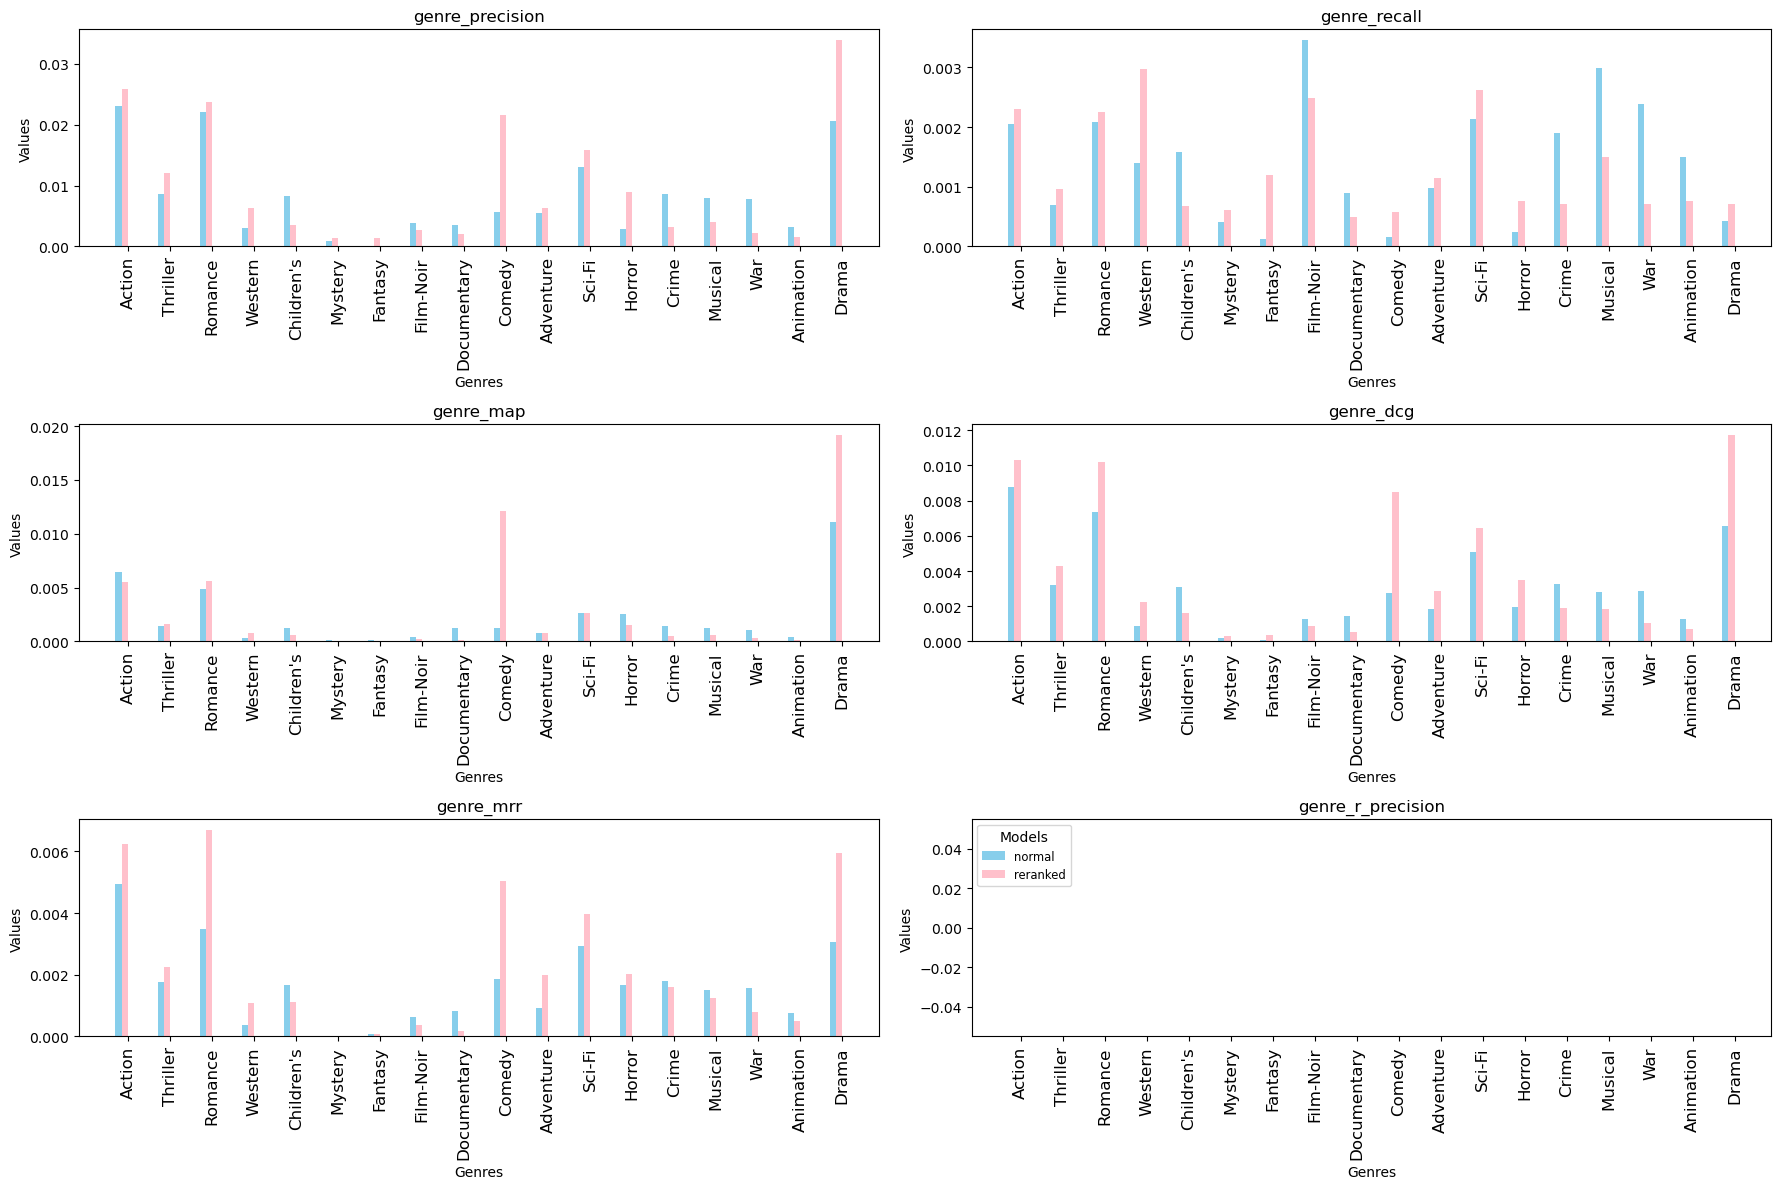

In [71]:
import matplotlib.pyplot as plt
import numpy as np


matrices = [model_gps[0], model_grs[0], model_gms[0], model_gdcgs[0], model_gmrrs[0], model_grps[0]]
matrices_2 = [model_gps[1], model_grs[1], model_gms[1], model_gdcgs[1], model_gmrrs[1], model_grps[1]]
# matrices_3 = [model_gps[2], model_grs[2], model_gms[2], model_gdcgs[2], model_gmrrs[2], model_grps[2]]
# matrices_4 = [model_gps[3], model_grs[3], model_gms[3], model_gdcgs[3], model_gmrrs[3], model_grps[3]]
# matrices_5 = [model_gps[4], model_grs[4], model_gms[4], model_gdcgs[4], model_gmrrs[4], model_grps[4]]
# matrices_6 = [model_gps[5], model_grs[5], model_gms[5], model_gdcgs[5], model_gmrrs[5], model_grps[5]]
# all_matrices = [matrices,matrices_2, matrices_3, matrices_4, matrices_5, matrices_6]

# matrices_2 = [
#     model_gp_2,
#     model_gr_2,
#     model_gm_2,
#     model_gdcg_2,
#     model_gmrr_2,
#     model_grp_2,
# ]
# matrices_3 = [
    
#     model_gp_3,
#     model_gr_3,
#     model_gm_3,
#     model_gdcg_3,
#     model_gmrr_3,
#     model_grp_3,
# ]

# values2 = matrices[1]
labels = unique_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(3, 2, figsize=(18, 12))
axs = axs.flatten()
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.15 # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(x - 3 * bar_width / 2, matrices[i], bar_width, color="skyblue", label="normal")
    axs[i].bar(x - 1 * bar_width / 2, matrices_2[i], bar_width, color="pink", label="reranked")
    # axs[i].bar(x +1 * bar_width / 2, matrices_3[i], bar_width, color="green", label="MF")
    # axs[i].bar(x + 3 * bar_width / 2, matrices_4[i], bar_width, color="orange", label="BPR")
    # axs[i].bar(x + 5 * bar_width / 2, matrices_5[i], bar_width, color="red", label="SVD")
    # axs[i].bar(x + 7 * bar_width / 2, matrices_6[i], bar_width, color="yellow", label="MostPop")
    # # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(unique_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)
    
# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)
plt.legend(handles, labels, loc='upper left', fontsize='small', title='Models')

# Adjust layout
plt.tight_layout()
plt.show()